# plot scCODA results for differential abundance (FigS3E)
- Compare ARI vs HC1

# Setup

In [1]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('dplyr')
quiet_library('viridis')
quiet_library('lmerTest')
quiet_library('broom.mixed')
quiet_library('rstatix')
quiet_library('data.table')
quiet_library('ggpubr')

Warning message:
“Failed to locate timezone database”
Warning message:
“package ‘lmerTest’ was built under R version 4.3.3”


In [2]:
# define file path
# define working path
data_path = '/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/certPro_scRNA/certPro_results'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/DA/figures'
meta_path = '/home/workspace/github/ra-longitudinal/metadata'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/DA/output_results'

if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))
proj_name = 'ALTRA_scRNA_sccoda_'

In [3]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", 
                    "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
ari_colors = c('#4C8CBD', '#F59F00', '#840032')
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 6, repr.plot.height = 6)

In [4]:
source('/home/workspace/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r')

# AIM1

In [5]:
# load aim1 frequency table
aim1_aifi_l3_freq = read_csv(file.path(data_path, 
                                       'ALTRA_scRNA_AIFI_L3_deepclean_certpro_AIM1_frequency_table.csv'),
                             show_col_types = FALSE) %>%
    mutate(status = factor(recode(Status_Xsec, 'ALTRA_healthy'='HC',
                                 'at_risk' = 'ARI'), levels = c('HC', 'ARI')))
aim1_aifi_l3_freq %>% head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency,pseudo_clr
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Activated memory B cell,KT00052,0,1,17478,CU1009,Female,24.65716,Negative,ARI,56,B140,at_risk,0.0000000000,5.721478e-05,-3.129493
Activated memory B cell,KT00056,5,6,12817,CU1007,Female,25.94834,Negative,ARI,42,B002,at_risk,0.0003928347,4.681283e-04,-1.334438
Activated memory B cell,KT00057,5,6,11946,CU1003,Female,21.12653,Positive,ARI,21,B002,at_risk,0.0004216918,5.022602e-04,-1.454036
Activated memory B cell,KT00058,3,4,17325,CU1002,Female,27.67950,Positive,ARI,78,B001,at_risk,0.0001740543,2.308802e-04,-1.750482
Activated memory B cell,KT00060,4,5,11642,CU1005,Female,31.80398,Negative,ARI,40,B002,at_risk,0.0003462304,4.294795e-04,-1.265923
Activated memory B cell,KT00063,2,3,16604,CU1011,Male,28.12331,Negative,ARI,39,B140,at_risk,0.0001211020,1.806794e-04,-2.086592


In [10]:
aim1_aifi_l3_freq%>%distinct(sample.sampleKitGuid, .keep_all = TRUE)%>%group_by(Status_Xsec)%>%tally()

Status_Xsec,n
<chr>,<int>
ALTRA_healthy,31
at_risk,45


In [11]:
# filter cell type that are too rare to do analysis
rare_celltype <- aim1_aifi_l3_freq %>% dplyr::filter(counts==0)%>%
    group_by(AIFI_L3_new)%>%tally()%>% arrange(desc(n))%>%
    filter(n>76/2)%>%
    pull(AIFI_L3_new)
rare_celltype

[1] "KLRF1+_GZMB+_CD27-_EM_CD8_uk1"  "Activated memory B cell_uk1"   
[3] "T2MBC_uk1"                      "Early memory B cell_uk1"       
[5] "KLRF1-_GZMB+_CD27-_mem_CD4_uk1" "BaEoMaP cell"                  
[7] "KLRF1-_GZMB+_CD27-_EM_CD8_uk1"  "ILC_uk1"                       
[9] "Prolif_T_uk1"

In [9]:
# run statistic test
freq_stats_wilcox <- aim1_aifi_l3_freq %>% filter(!AIFI_L3_new%in%rare_celltype)%>% 
    mutate(Status_Xsec = factor(Status_Xsec, levels = c('ALTRA_healthy', 'at_risk')))%>%
    group_by(AIFI_L3_new) %>%
    rstatix::wilcox_test(pseudo_clr ~ Status_Xsec, paired = FALSE) %>%
    rstatix::adjust_pvalue(method = "BH") %>%
    rstatix::add_significance("p.adj") 
freq_stats_wilcox%>%arrange(p.adj)%>%head(10)

AIFI_L3_new,.y.,group1,group2,n1,n2,statistic,p,p.adj,p.adj.signif
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
CM CD4 T cell,pseudo_clr,ALTRA_healthy,at_risk,31,45,429,0.00418,0.1672000,ns
Intermediate monocyte,pseudo_clr,ALTRA_healthy,at_risk,31,45,413,0.00235,0.1672000,ns
Erythrocyte,pseudo_clr,ALTRA_healthy,at_risk,31,45,944,0.00875,0.2333333,ns
Proliferating T cell,pseudo_clr,ALTRA_healthy,at_risk,31,45,462,0.01240,0.2480000,ns
KLRB1+ memory CD8 Treg,pseudo_clr,ALTRA_healthy,at_risk,31,45,903,0.02970,0.4752000,ns
ASDC,pseudo_clr,ALTRA_healthy,at_risk,31,45,850,0.10800,0.4884211,ns
ASDC_uk1_B,pseudo_clr,ALTRA_healthy,at_risk,31,45,548,0.11600,0.4884211,ns
C1Q+ CD16 monocyte,pseudo_clr,ALTRA_healthy,at_risk,31,45,509,0.04650,0.4884211,ns
CD56bright NK cell,pseudo_clr,ALTRA_healthy,at_risk,31,45,857,0.09300,0.4884211,ns


### find reference cell types for sccoda

In [34]:
# find cell type that have more than 5 counts for each samples
rare_celltypes = aim1_aifi_l3_freq %>% dplyr::filter(counts<5)%>% 
    distinct(AIFI_L3_new)%>% pull(AIFI_L3_new)
length(rare_celltypes)

reference_celltypes = freq_stats_wilcox%>%filter(p>0.5 & (!AIFI_L3_new%in% rare_celltypes))
reference_celltypes%>% write_csv(file.path(output_path, 'ALTRA_DA_AIM1_wilcox_reference_celltypes.csv'))

[1] 65

### run glm for aim1

In [37]:
aim1_aifi_l3_freq%>% head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency,pseudo_clr
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Activated memory B cell,KT00052,0,1,17478,CU1009,Female,24.65716,Negative,at_risk,56,B140,at_risk,0.0000000000,5.721478e-05,-3.129493
Activated memory B cell,KT00056,5,6,12817,CU1007,Female,25.94834,Negative,at_risk,42,B002,at_risk,0.0003928347,4.681283e-04,-1.334438
Activated memory B cell,KT00057,5,6,11946,CU1003,Female,21.12653,Positive,at_risk,21,B002,at_risk,0.0004216918,5.022602e-04,-1.454036
Activated memory B cell,KT00058,3,4,17325,CU1002,Female,27.67950,Positive,at_risk,78,B001,at_risk,0.0001740543,2.308802e-04,-1.750482
Activated memory B cell,KT00060,4,5,11642,CU1005,Female,31.80398,Negative,at_risk,40,B002,at_risk,0.0003462304,4.294795e-04,-1.265923
Activated memory B cell,KT00063,2,3,16604,CU1011,Male,28.12331,Negative,at_risk,39,B140,at_risk,0.0001211020,1.806794e-04,-2.086592


In [39]:
# add batch correction 
aim1_aifi_l3_freq <- aim1_aifi_l3_freq%>%
    mutate(batch_corr = factor(if_else(file.batchID=='B182', file.batchID, 'other')), 
          scale_age = scale(age), scale_bmi = scale(BMI))

In [51]:
# run statistic model for CLR
aim1_clr_glm <- aim1_aifi_l3_freq %>% filter(!AIFI_L3_new%in%rare_celltype)%>% 
    # filter(file.batchID!='B182')%>% 
    mutate(Status_Xsec = factor(Status_Xsec, levels = c('ALTRA_healthy', 'at_risk')))%>%
    group_by(AIFI_L3_new) %>% 
    group_modify(~RunGlmFreq(.x, formula='pseudo_clr ~ scale_age + subject.biologicalSex + scale_bmi + batch_corr + Status_Xsec', 
                           cell_type=.y$AIFI_L3_new))

In [52]:
aim1_clr_glm_status <- aim1_clr_glm %>% filter(term=='Status_Xsecat_risk') %>% ungroup()%>%
    rstatix::adjust_pvalue(method = "BH")%>% arrange(p.value)

In [54]:
aim1_clr_glm_status%>%head(10)

AIFI_L3_new,term,estimate,std.error,statistic,p.value,cell_type,p.value.adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
ISG+ memory CD4 T cell,Status_Xsecat_risk,-0.4907535,0.2310678,-2.123851,0.03721785,ISG+ memory CD4 T cell,0.6049069
KLRF1- GZMB+ CD27- memory CD4 T cell,Status_Xsecat_risk,1.0564830,0.5305439,1.991320,0.05034935,KLRF1- GZMB+ CD27- memory CD4 T cell,0.6049069
CM CD4 T cell,Status_Xsecat_risk,0.2262217,0.1163652,1.944067,0.05590737,CM CD4 T cell,0.6049069
IL1B+ CD14 monocyte,Status_Xsecat_risk,-0.6551436,0.3372842,-1.942408,0.05611157,IL1B+ CD14 monocyte,0.6049069
GZMK+ CD27+ EM CD8 T cell,Status_Xsecat_risk,0.2854958,0.1686527,1.692803,0.09493951,GZMK+ CD27+ EM CD8 T cell,0.6049069
ISG+ cDC2,Status_Xsecat_risk,-0.3724036,0.2214681,-1.681523,0.09711813,ISG+ cDC2,0.6049069
ISG+ naive CD8 T cell,Status_Xsecat_risk,-0.4252646,0.2575512,-1.651185,0.10318064,ISG+ naive CD8 T cell,0.6049069
ISG+ CD56dim NK cell,Status_Xsecat_risk,-0.4710476,0.2872669,-1.639756,0.10554269,ISG+ CD56dim NK cell,0.6049069
CD56bright NK cell,Status_Xsecat_risk,-0.2409673,0.1520997,-1.584271,0.11763972,CD56bright NK cell,0.6049069


In [144]:
# get significant cell types
sig_celltypes = filter(aim1_clr_glm_status, p.value.adj<0.1)%>%pull(AIFI_L3_new)


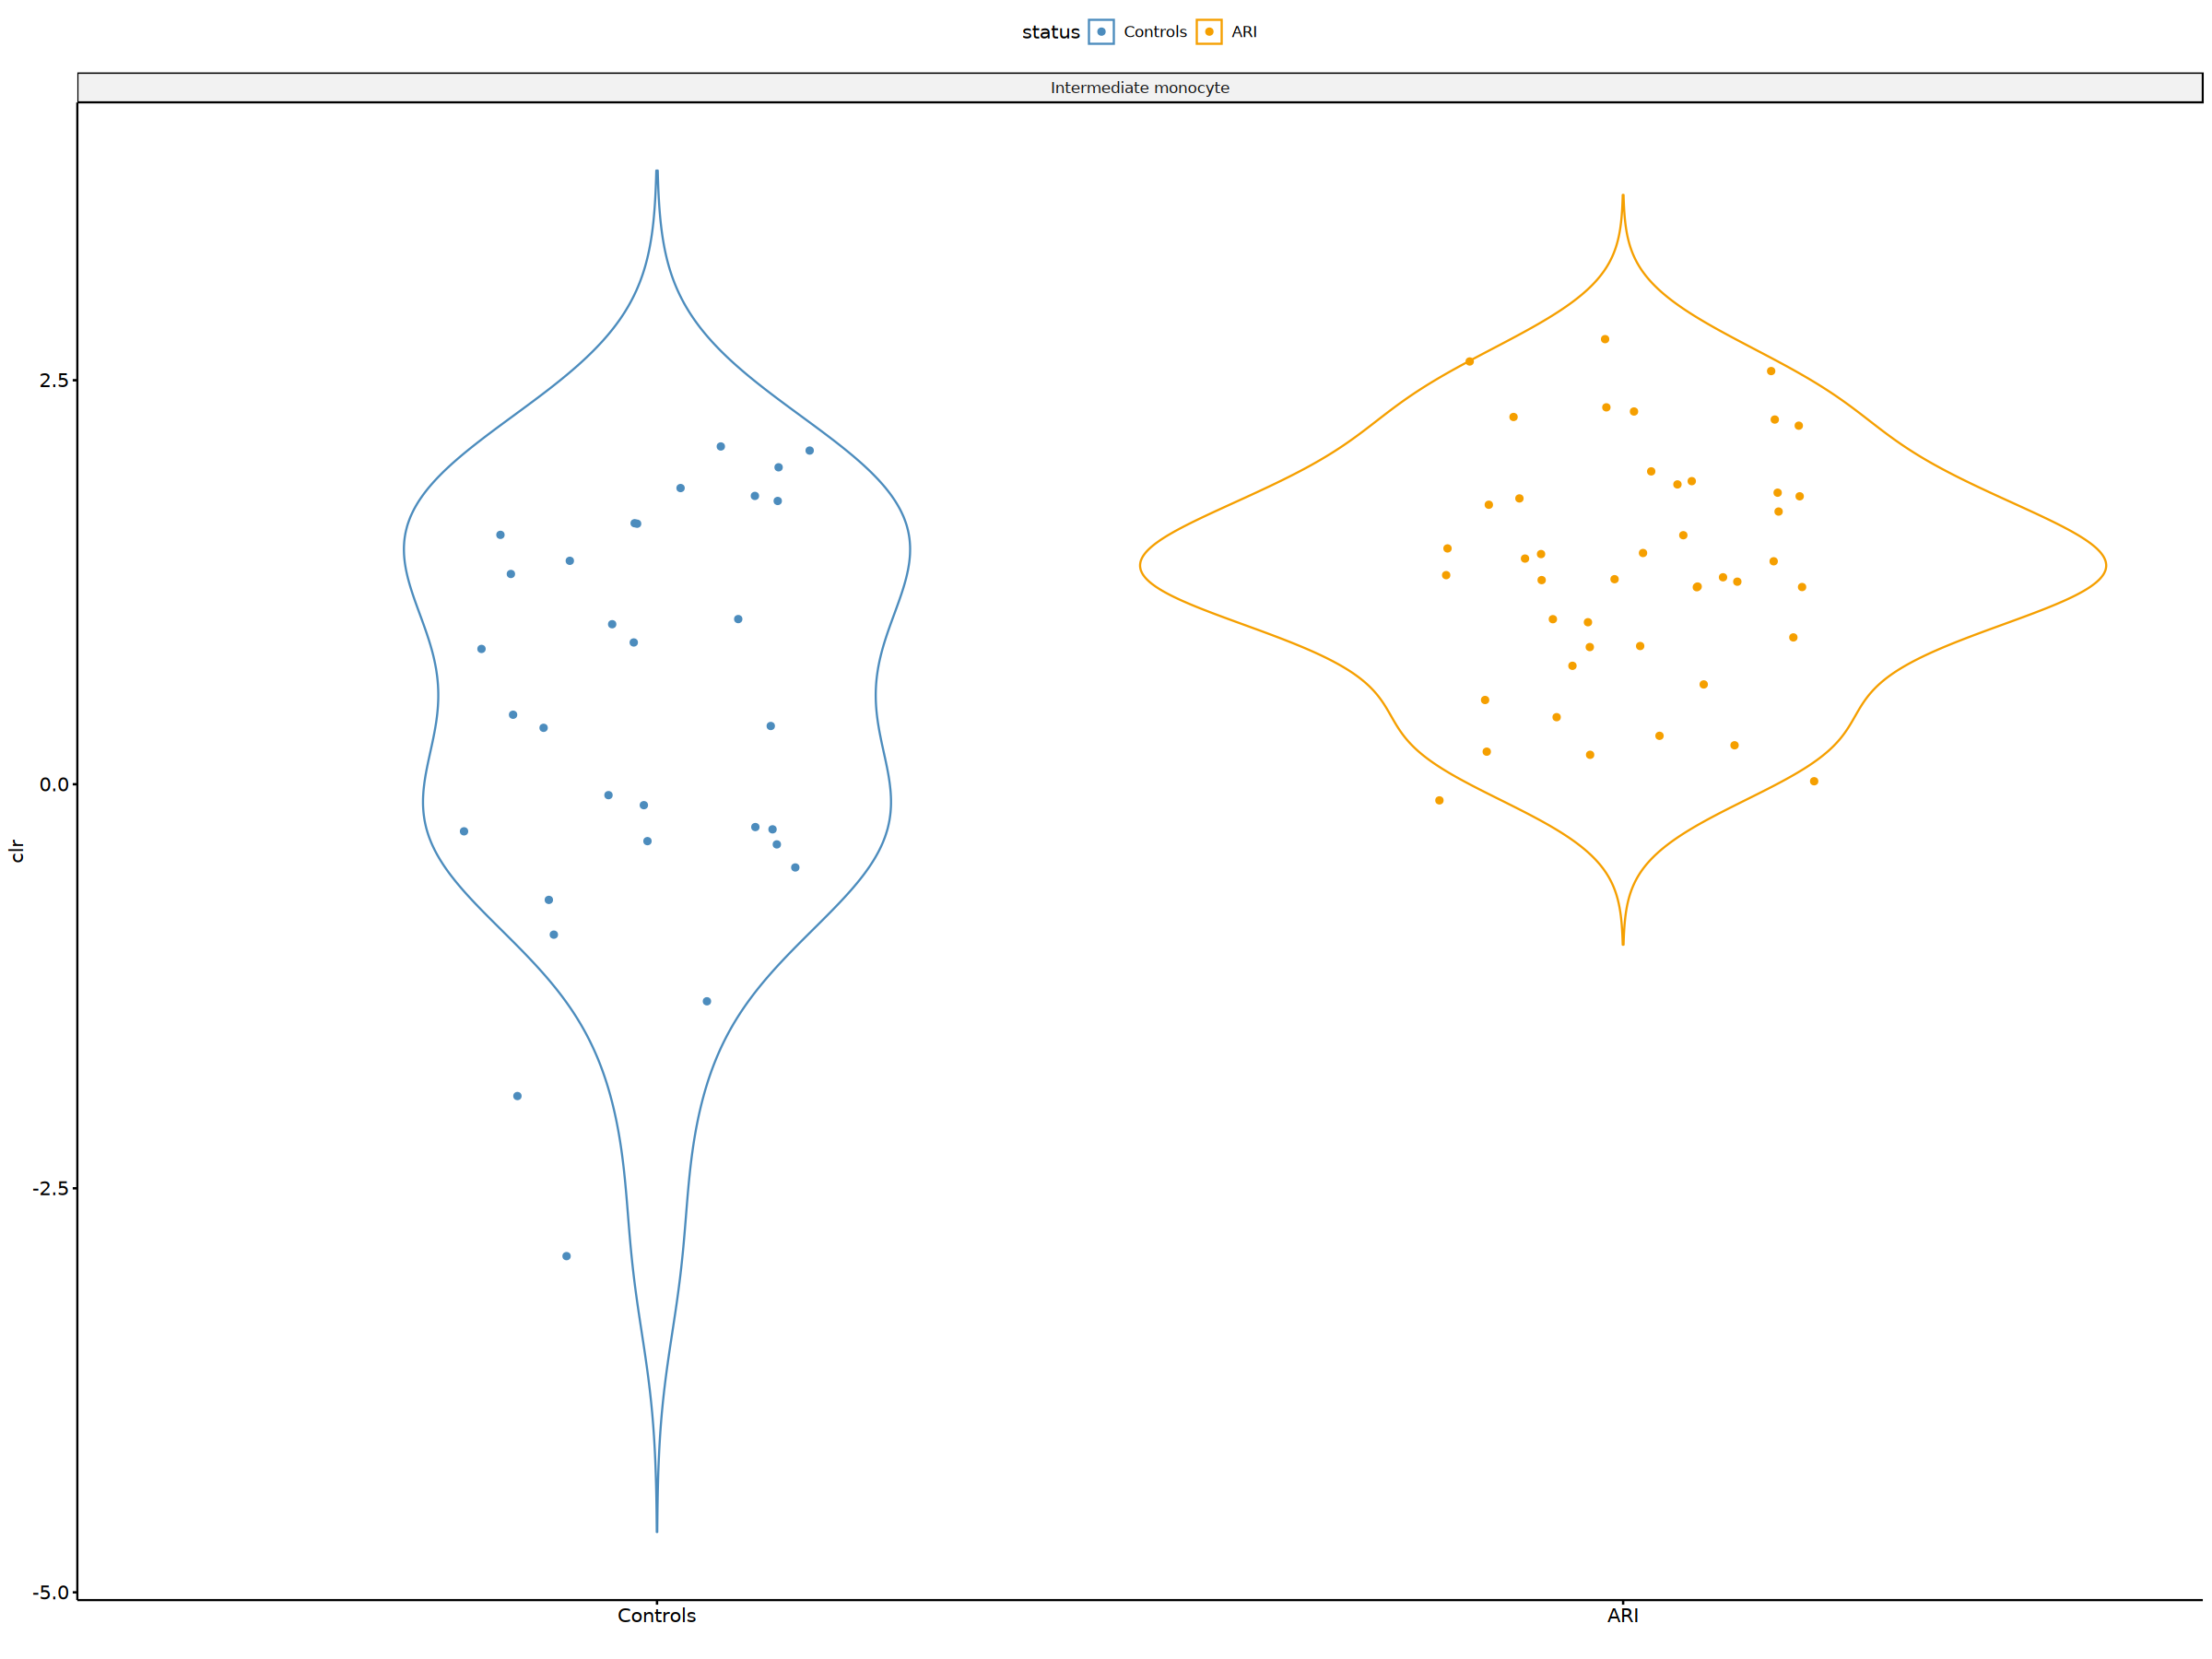

In [150]:
# plot the significant results
p1 <- aim1_aifi_l3_freq %>%  filter(AIFI_L3_new%in%sig_celltypes)%>%
    ggpubr::ggviolin(x='status', y='pseudo_clr', add = "jitter", ylab='clr', xlab='',
                     color='status', palette = ari_con_colors) +
    facet_wrap(vars(AIFI_L3_new), scales = 'free_y') 
p1
ggsave(file.path(fig_path, paste0(proj_name,'AIM1_DA_sig_freq_plot.png')),
       width=4, height=4)

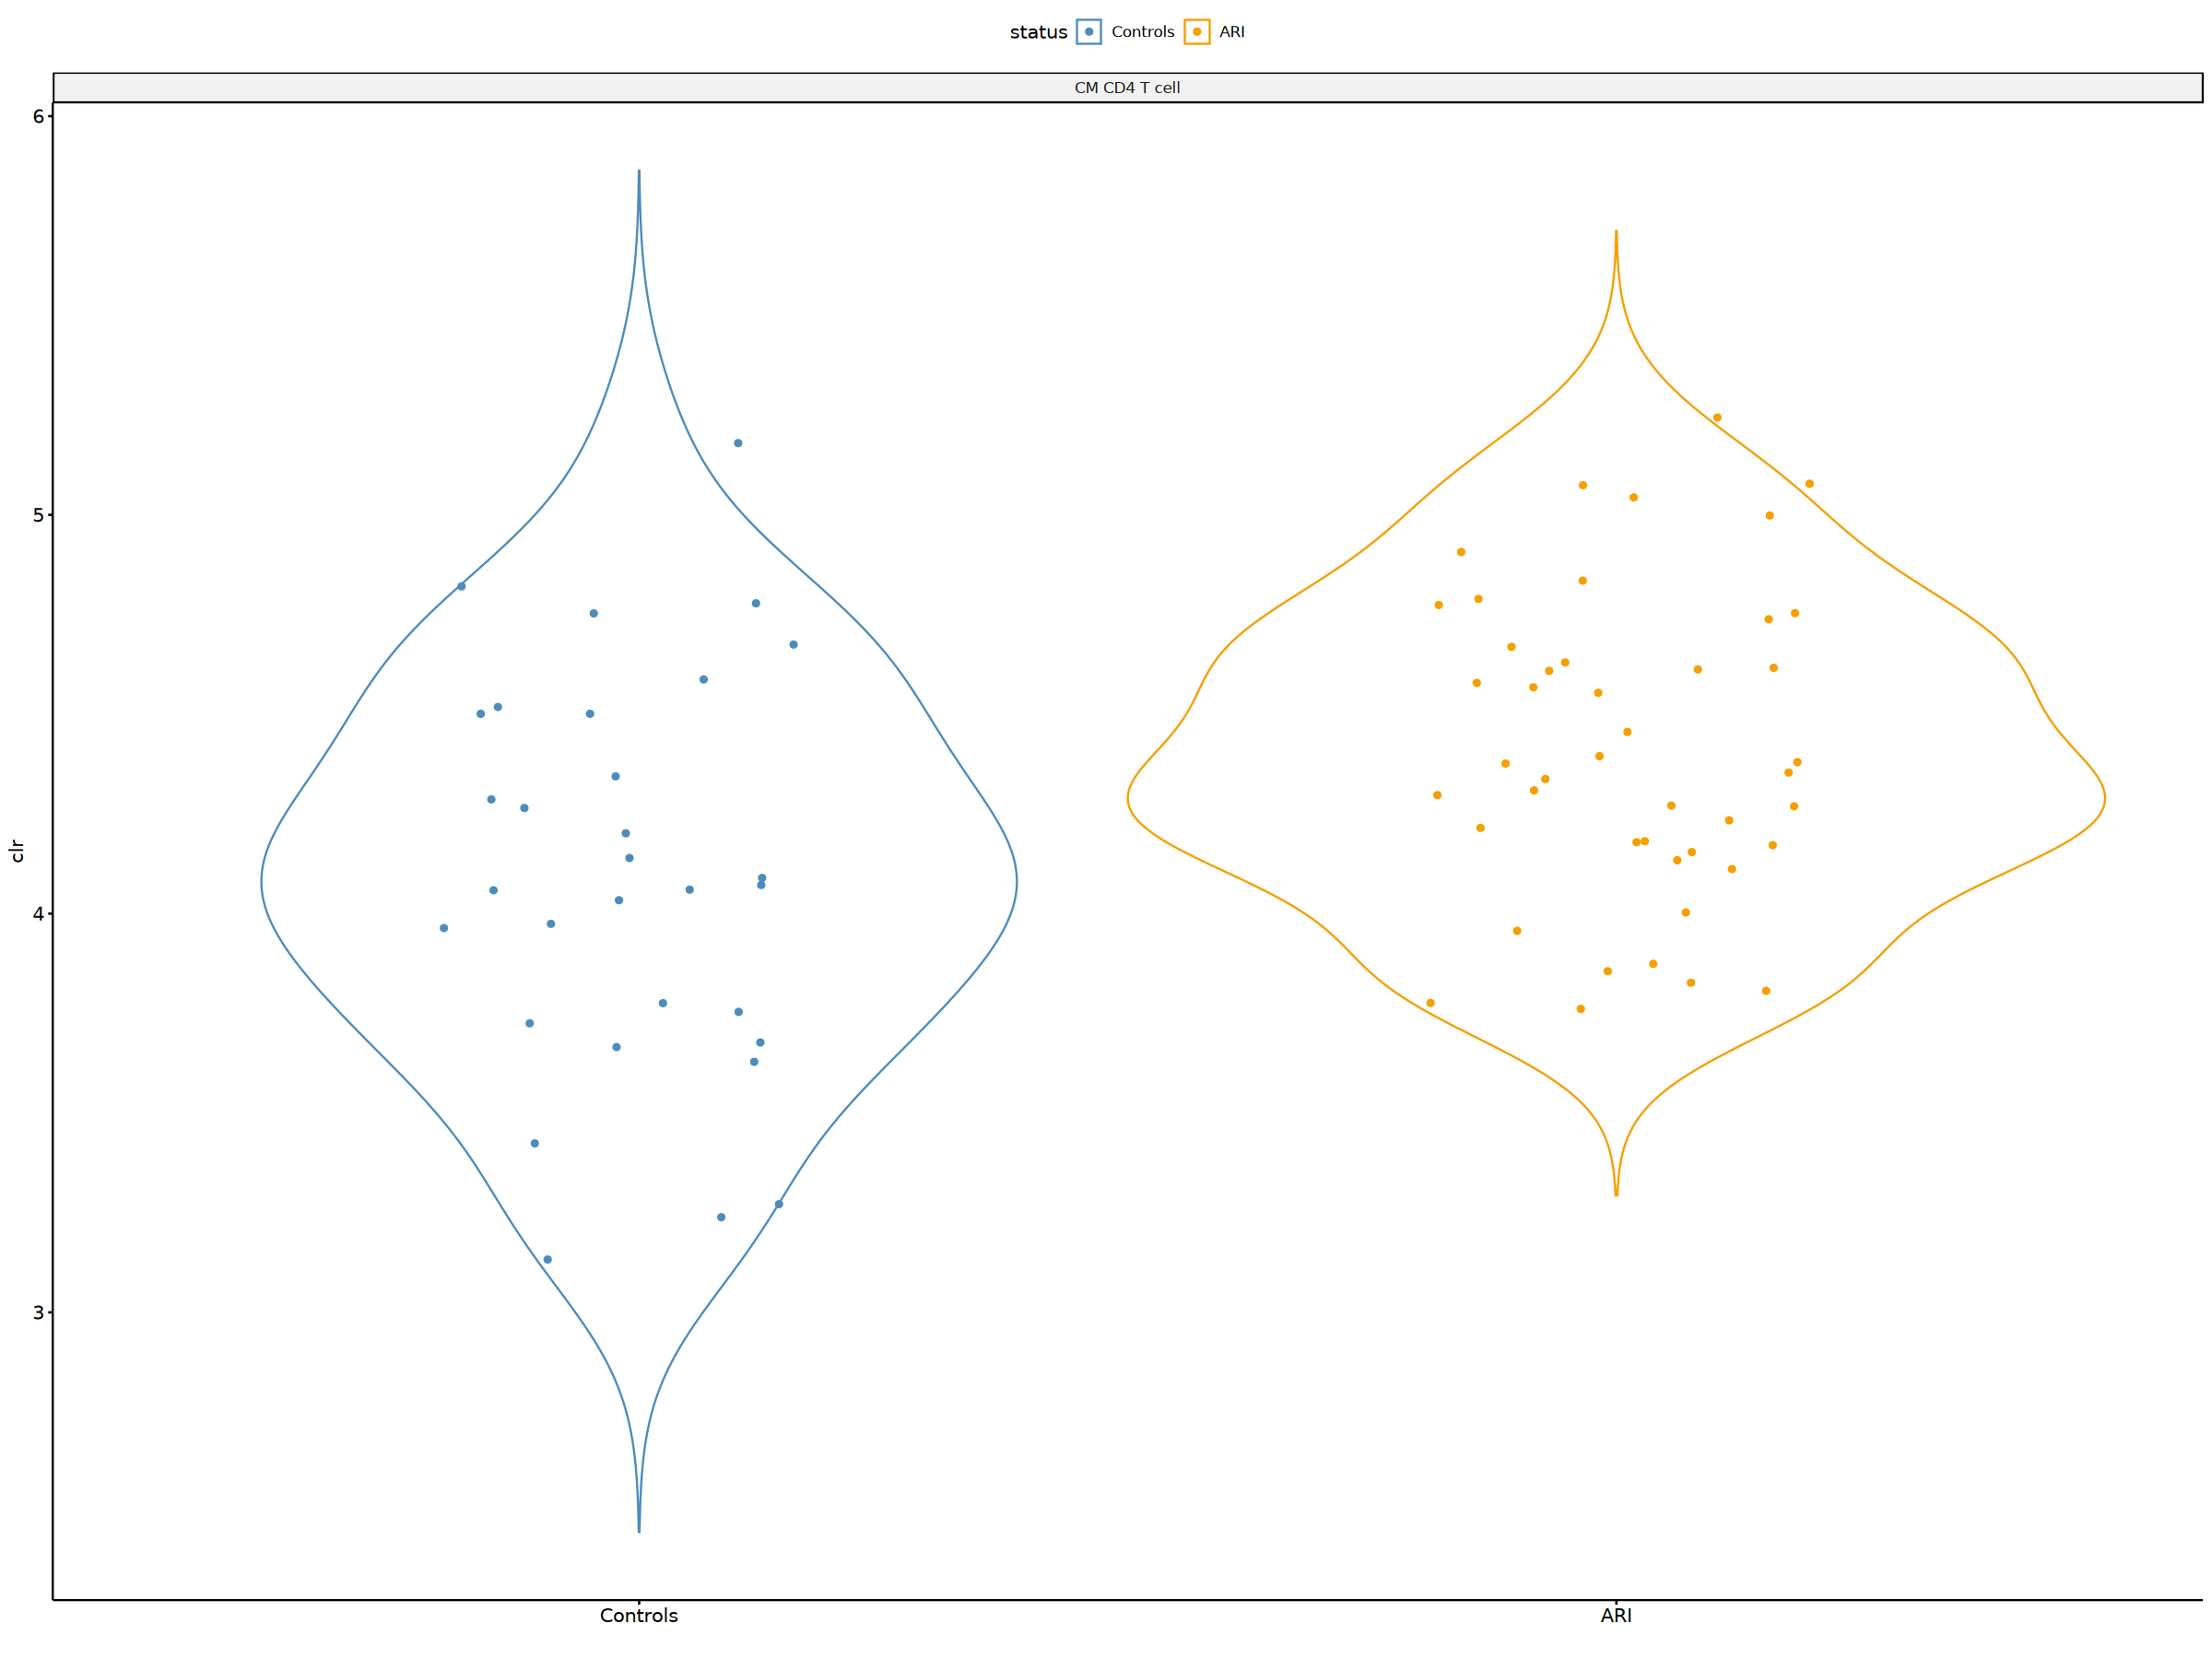

In [151]:
# plot the significant results
p1 <- aim1_aifi_l3_freq %>%  filter(AIFI_L3_new=='CM CD4 T cell')%>%
    ggpubr::ggviolin(x='status', y='pseudo_clr', add = "jitter", ylab='clr', xlab='',
                     color='status', palette = ari_con_colors) +
    facet_wrap(vars(AIFI_L3_new), scales = 'free_y') 
p1
ggsave(file.path(fig_path, paste0(proj_name,'AIM1_DA_CD4CM_freq_plot.png')),
       width=4, height=4)

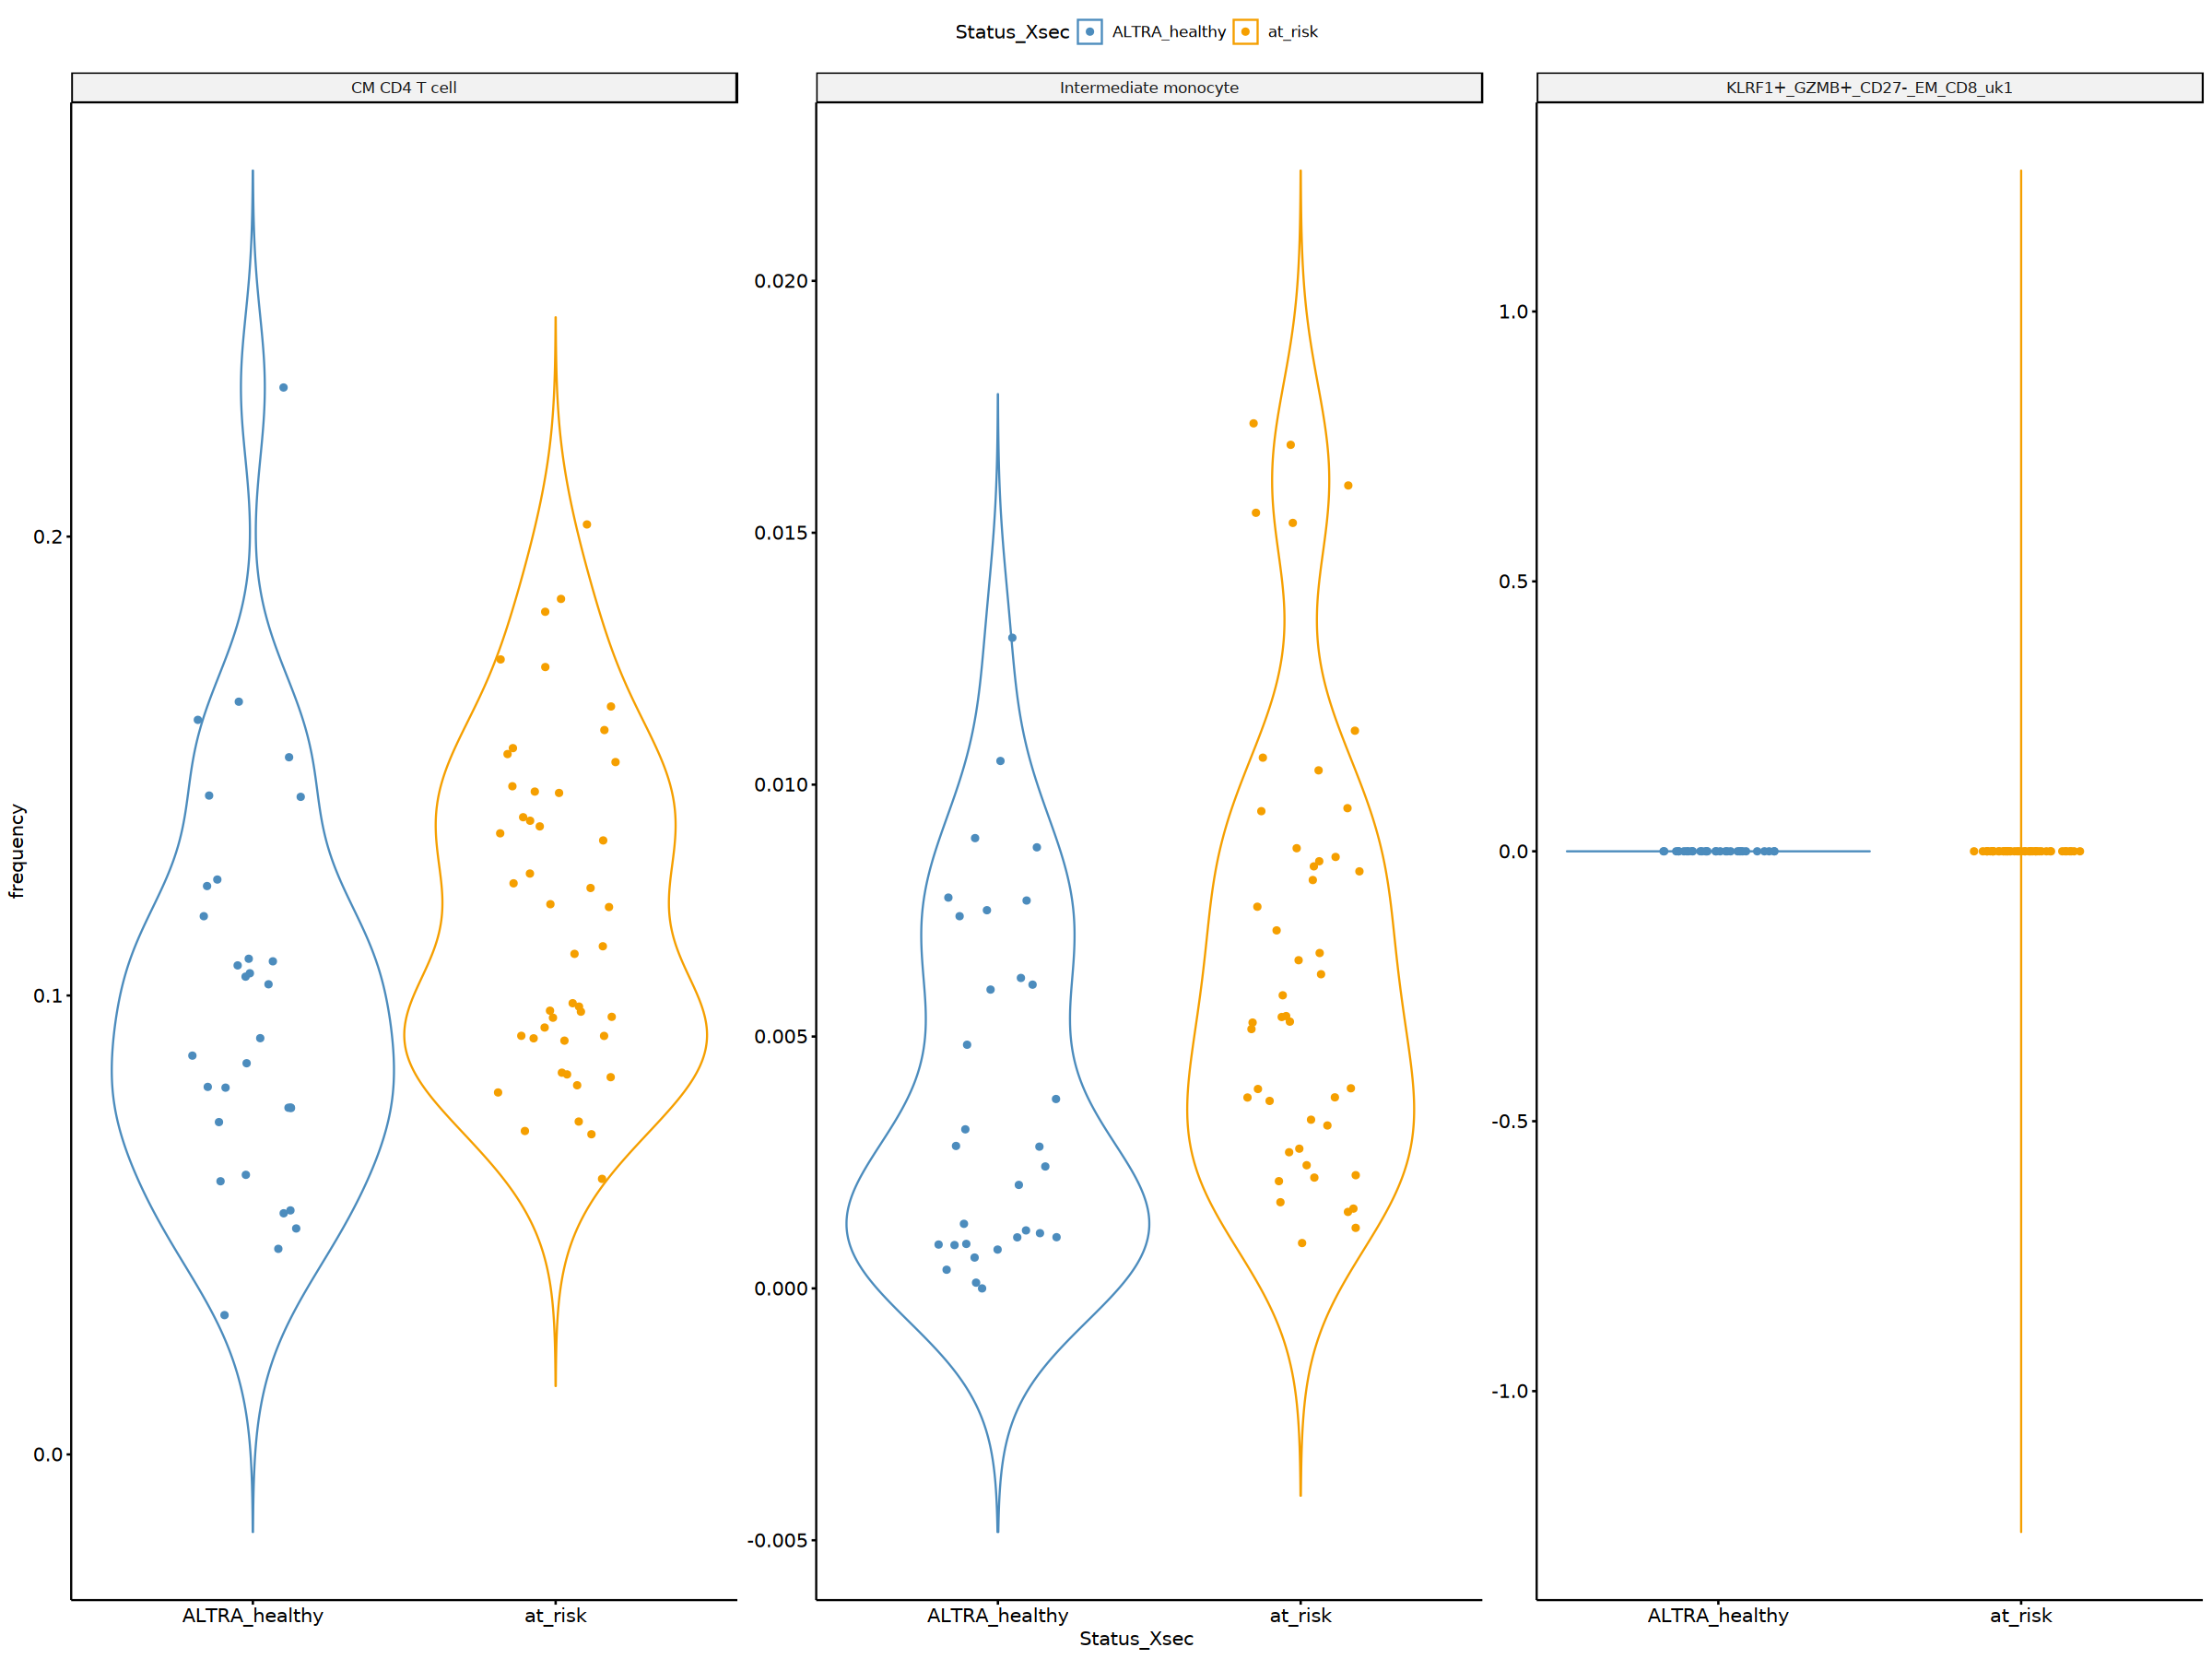

In [89]:
# plot the significant results
p1 <- da_sig %>%
    ggpubr::ggviolin(x='Status_Xsec', y='frequency', add = "jitter", 
                     color='Status_Xsec', palette = ari_con_colors) +
    facet_wrap(vars(AIFI_L3_new), scales = 'free_y')
p1
ggsave(file.path(fig_path, paste0(proj_name,'AIM1_DA_sig_freq_plot.png')),
       width=12, height=4)

In [97]:
# save aim1 frequency DA results
aim1_clr_glm_status %>% write_csv(file.path(output_path, paste0(proj_name, 'AIM1_frequency_DA_results.csv')))

In [8]:
# save aim1 frequency DA results
aim1_clr_glm_status <- read_csv(file.path(output_path, paste0(proj_name, 'AIM1_frequency_DA_results.csv')))

Rows: 80 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): AIFI_L3_new, term, cell_type
dbl (5): estimate, std.error, statistic, p.value, p.value.adj

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [12]:
aim1_clr_glm_status%>% arrange(desc(p.value))%>% head(10)

AIFI_L3_new,term,estimate,std.error,statistic,p.value,cell_type,p.value.adj
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
CD4 MAIT,Status_Xsecat_risk,-0.001386476,0.1806064,-0.007676785,0.9938964,CD4 MAIT,0.9938964
KLRB1+ memory CD4 Treg,Status_Xsecat_risk,-0.008203443,0.1024260,-0.080091446,0.9363899,KLRB1+ memory CD4 Treg,0.9482429
DN T cell,Status_Xsecat_risk,-0.010717083,0.1284077,-0.083461396,0.9337195,DN T cell,0.9482429
GZMK+ memory CD4 Treg,Status_Xsecat_risk,-0.012016536,0.1418611,-0.084706379,0.9327332,GZMK+ memory CD4 Treg,0.9482429
GZMK- CD27+ EM CD8 T cell,Status_Xsecat_risk,-0.017405166,0.2004150,-0.086845618,0.9310387,GZMK- CD27+ EM CD8 T cell,0.9482429
Adaptive NK cell_uk1_T,Status_Xsecat_risk,-0.032655934,0.3347292,-0.097559265,0.9225572,Adaptive NK cell_uk1_T,0.9482429
cDC1,Status_Xsecat_risk,-0.021156110,0.1430955,-0.147846098,0.8828833,cDC1,0.9482429
SOX4+ naive CD4 T cell,Status_Xsecat_risk,-0.040028458,0.2272923,-0.176110039,0.8607088,SOX4+ naive CD4 T cell,0.9432426
GZMK+ CD56dim NK cell,Status_Xsecat_risk,-0.028766615,0.1229271,-0.234013564,0.8156479,GZMK+ CD56dim NK cell,0.9062755


# plot results for sccoda

In [6]:
aim1_aifi_l3_freq%>% head()

AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency,pseudo_clr
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
Activated memory B cell,KT00052,0,1,17478,CU1009,Female,24.65716,Negative,ARI,56,B140,at_risk,0.0000000000,5.721478e-05,-3.129493
Activated memory B cell,KT00056,5,6,12817,CU1007,Female,25.94834,Negative,ARI,42,B002,at_risk,0.0003928347,4.681283e-04,-1.334438
Activated memory B cell,KT00057,5,6,11946,CU1003,Female,21.12653,Positive,ARI,21,B002,at_risk,0.0004216918,5.022602e-04,-1.454036
Activated memory B cell,KT00058,3,4,17325,CU1002,Female,27.67950,Positive,ARI,78,B001,at_risk,0.0001740543,2.308802e-04,-1.750482
Activated memory B cell,KT00060,4,5,11642,CU1005,Female,31.80398,Negative,ARI,40,B002,at_risk,0.0003462304,4.294795e-04,-1.265923
Activated memory B cell,KT00063,2,3,16604,CU1011,Male,28.12331,Negative,ARI,39,B140,at_risk,0.0001211020,1.806794e-04,-2.086592


In [10]:
# load sccoda results
sccoda_res = read_csv(
    '/home/workspace/private/ra-cohort-ide/ALTRA_revision/frequency_table/output_results/ALTRA_scRNA_DA_reanalysis__model_results_with_ref_shift.csv',
    show_col_types = FALSE, col_select = -1)%>% rename('cell_type'='Cell Type') %>% rename('log2FC'='log2-fold change')
sccoda_res%>% head()

New names:
• `` -> `...1`


Covariate,cell_type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2FC,ref_celltype,pass_fdr_0_1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
status[T.ARI],ASDC,0,-0.153,0.160,0.061,0.5086667,26.92689,-0.03928675,Core naive B cell,FALSE
status[T.ARI],ASDC_uk1_B,0,-0.141,0.161,0.061,0.5598667,21.69594,-0.03928675,Core naive B cell,FALSE
status[T.ARI],Activated memory B cell,0,-0.142,0.150,0.049,0.4261333,24.95628,-0.03928675,Core naive B cell,FALSE
status[T.ARI],Activated memory B cell_uk1,0,-0.188,0.180,0.066,0.4693333,18.21281,-0.03928675,Core naive B cell,FALSE
status[T.ARI],Adaptive NK cell,0,-0.118,0.264,0.083,0.5347333,89.22179,-0.03928675,Core naive B cell,FALSE
status[T.ARI],Adaptive NK cell_uk1_T,0,-0.189,0.150,0.073,0.6130000,30.39036,-0.03928675,Core naive B cell,FALSE


### ouput table s14

In [20]:
# make table s14
sccoda_tables14 <- sccoda_res %>% 
    rename('Cell type' ='cell_type', 'Reference Cell type' = 'ref_celltype',
           "FDR < 0.1" ='pass_fdr_0_1' )%>%
    mutate(Covariate = if_else(Covariate == 'status[T.ARI]', 'ARI', Covariate))
sccoda_tables14%>%head()
sccoda_tables14%>%write_csv(file.path(output_path, 'Table_S14_DA_scCODA_results.csv'))

Covariate,Cell type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2FC,Reference Cell type,FDR < 0.1
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
ARI,ASDC,0,-0.153,0.160,0.061,0.5086667,26.92689,-0.03928675,Core naive B cell,FALSE
ARI,ASDC_uk1_B,0,-0.141,0.161,0.061,0.5598667,21.69594,-0.03928675,Core naive B cell,FALSE
ARI,Activated memory B cell,0,-0.142,0.150,0.049,0.4261333,24.95628,-0.03928675,Core naive B cell,FALSE
ARI,Activated memory B cell_uk1,0,-0.188,0.180,0.066,0.4693333,18.21281,-0.03928675,Core naive B cell,FALSE
ARI,Adaptive NK cell,0,-0.118,0.264,0.083,0.5347333,89.22179,-0.03928675,Core naive B cell,FALSE
ARI,Adaptive NK cell_uk1_T,0,-0.189,0.150,0.073,0.6130000,30.39036,-0.03928675,Core naive B cell,FALSE


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


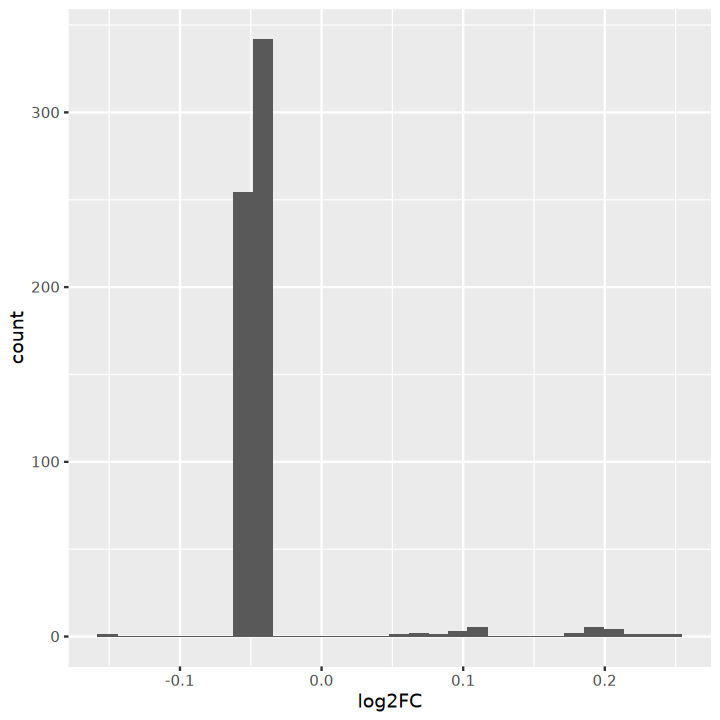

In [21]:
sccoda_res%>% ggplot(aes(x=log2FC)) + geom_histogram()

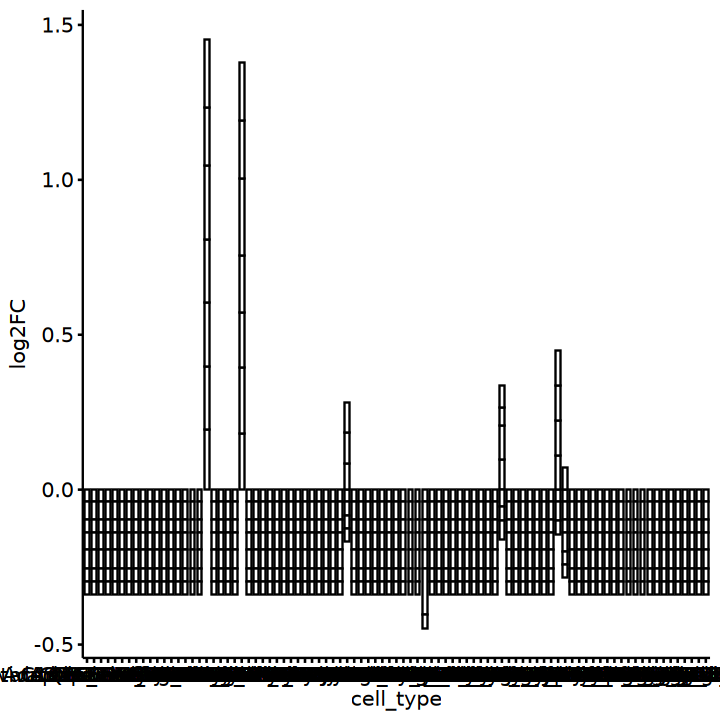

In [78]:
sccoda_res%>% ggbarplot(x='cell_type', y='log2FC')

In [58]:
sccoda_res%>% distinct(ref_celltype)%>% nrow()

[1] 7

In [55]:
sccoda_res%>% filter(pass_fdr_0_1) %>% group_by(cell_type) %>% tally()

cell_type,n
<chr>,<int>
CM CD4 T cell,7
Core CD14 monocyte,7
GZMK+ CD27+ EM CD8 T cell,3
ISG+ CD14 monocyte,1
Intermediate monocyte,4
KLRF1- GZMB+ CD27- EM CD8 T cell,4
KLRF1- GZMB+ CD27- memory CD4 T cell,1


In [70]:
sccoda_res_logfc = sccoda_res %>% group_by(cell_type) %>% summarise(log2FC = mean(`log2-fold change`))
sccoda_res_logfc%>% write_csv(file.path(output_path, paste0(proj_name,'sccoda_average_logfc.csv')))

cell_type,log2FC
<chr>,<dbl>
ASDC,-0.04846127
ASDC_uk1_B,-0.04846127
Activated memory B cell,-0.04846127
Activated memory B cell_uk1,-0.04846127
Adaptive NK cell,-0.04846127
Adaptive NK cell_uk1_T,-0.04846127
BaEoMaP cell,-0.04846127
C1Q+ CD16 monocyte,-0.04846127
CD14+ cDC2,-0.04846127


## plot fig S3E

In [65]:
sig_celltypes = c('Core CD14 monocyte', 'CM CD4 T cell')

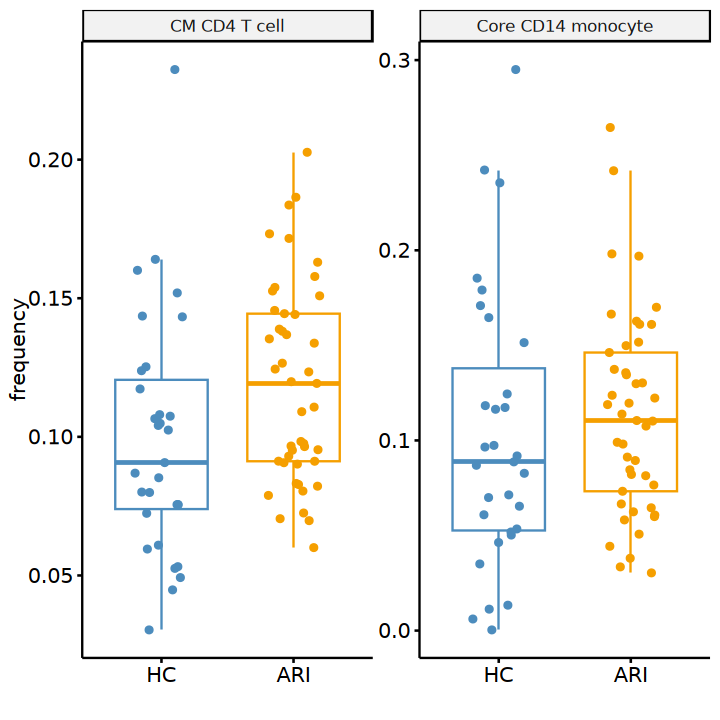

In [66]:
# plot the significant results
p1 <- aim1_aifi_l3_freq %>%  filter(AIFI_L3_new%in%sig_celltypes)%>%
    ggpubr::ggboxplot(x='status', y='frequency', add = "jitter", ylab='frequency', xlab='', legend='none',
                     color='status', palette = ari_colors) +
    facet_wrap(vars(AIFI_L3_new), scales = 'free_y') 
p1
ggsave(file.path(fig_path, paste0(proj_name,'AIM1_DA_sig_freq_plot.pdf')),
       width=6, height=4)